/var/folders/wr/pcnt_8y52jq29rms2mzr5vz80000gn/T/ipykernel_53901/2522635228.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  X = df.groupby('cycle number').apply(lambda x: x['freq/Hz'].values).values
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


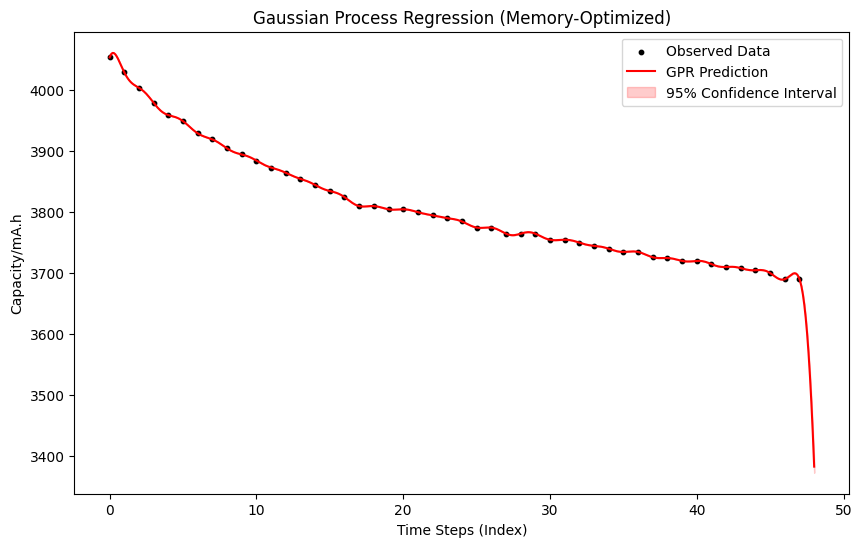

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load the dataset
df = pd.read_csv("/Users/apple/Desktop/eis-ml/data/03-06-24/A1.csv")

# Data preprocessing
df = df.dropna()  # Drop empty rows
df = df.loc[(df['cycle number'] != 0)].copy()  # Drop 0th cycle
df.rename(columns={'Unnamed: 0': 'Imaginary Resistance'}, inplace=True)

# Filter EIS data
df = df[(df['freq/Hz'] > 0.2) & (df['freq/Hz'] <= 20000)]

# Ordering by cycle and frequency
cycle_numbers = df['cycle number'].unique()
df = df.sort_values(by=['cycle number', 'freq/Hz'])

# Extract features (X) and target (y)
X = df.groupby('cycle number').apply(lambda x: x['freq/Hz'].values).values
y = df.groupby('cycle number')['Capacity/mA.h'].mean().values

# Reshape data for GPR
X = np.arange(len(y)).reshape(-1, 1)
y = np.array(y)

# Define and train the Gaussian Process model
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X, y)

# Make predictions
X_pred = np.linspace(0, len(y), 500).reshape(-1, 1)
y_pred, sigma = gp.predict(X_pred, return_std=True)

# Save the model
joblib.dump(gp, 'gpr_battery_model.jpg')

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, c='k', label='Observed Data', s=10)
plt.plot(X_pred, y_pred, 'r-', label='GPR Prediction')
plt.fill_between(X_pred.ravel(), y_pred - 1.96 * sigma, y_pred + 1.96 * sigma, 
                 alpha=0.2, color='red', label='95% Confidence Interval')
plt.xlabel('Time Steps (Index)')
plt.ylabel('Capacity/mA.h')
plt.title('Gaussian Process Regression (Memory-Optimized)')
plt.legend()
plt.show()